# CLASE01: El Poder de la Analítica de Datos

Bienvenido a este cuaderno interactivo. La analítica de datos no es solo generar gráficos bonitos, es transformar información cruda en **decisiones estratégicas y rentables**. 

A continuación, exploraremos **dos ejemplos diferentes** que demuestran el impacto real de la analítica en los negocios:
1. **Optimización de Inventarios en E-commerce** (Analítica Descriptiva y Prescriptiva).
2. **Predicción de Abandono de Clientes - Churn** (Analítica Predictiva y Machine Learning).

--- 
## Ejemplo 1: Optimización de Inventarios en E-commerce

Imagina que manejas una tienda online con miles de productos. Tener demasiado stock inmoviliza capital; tener muy poco genera pérdidas de ventas. Vamos a simular datos de ventas diarias para identificar qué productos requieren una estrategia automatizada de reabastecimiento.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style='whitegrid')

# Simulación de datos para 5 productos clave durante 90 días
np.random.seed(42)
dias = 90
productos = ['Laptop Pro', 'Smartphone X', 'Auriculares BT', 'Monitor 4K', 'Teclado Mecánico']

data = []
for prod in productos:
    demanda_base = np.random.randint(10, 50)
    tendencia = np.random.choice([-0.1, 0.05, 0.2])
    for dia in range(1, dias + 1):
        demanda = max(0, int(demanda_base + tendencia * dia + np.random.normal(0, 5)))
        data.append({'Dia': dia, 'Producto': prod, 'Demanda': demanda})

df_ventas = pd.DataFrame(data)
tabla = df_ventas.pivot_table(index='Dia', columns='Producto', values='Demanda')
tabla.head()

Producto,Auriculares BT,Laptop Pro,Monitor 4K,Smartphone X,Teclado Mecánico
Dia,,,,,
1,35.0,50.0,58.0,36.0,11.0
2,38.0,44.0,45.0,35.0,10.0
3,46.0,41.0,46.0,40.0,13.0
4,41.0,58.0,50.0,43.0,7.0
5,49.0,47.0,63.0,38.0,14.0


### Análisis de variabilidad y punto de reorden
# Inventario de Seguridad y Punto de Reorden

Imagina que tienes una tienda y vendes productos todos los días.  
A veces la gente compra más de lo esperado, otras veces menos.  
Para no quedarte sin stock, necesitas un **colchón de seguridad**.

## Inventario de Seguridad
Es como tener un "plan B": una reserva extra de productos que te protege cuando la demanda sube inesperadamente.  
Piensa en ello como tener siempre unas cuantas botellas de agua guardadas en casa por si un día hace mucho calor.

## Punto de Reorden
Es el momento en el que debes pedir más productos antes de que se acaben.  
Por ejemplo: si sabes que normalmente vendes 10 botellas al día y tu proveedor tarda 3 días en entregarlas, entonces cuando te queden 30 botellas deberías hacer el pedido.  
Así, nunca llegas al punto de quedarte sin nada.

## En resumen
- **Inventario de Seguridad** = tu reserva extra para imprevistos.  
- **Punto de Reorden** = el aviso que te dice “¡es hora de pedir más!”.  

De esta manera, evitas rupturas de stock y mantienes a tus clientes felices.


In [16]:
# Calculamos estadísticas clave por producto
resumen_inventario = df_ventas.groupby('Producto')['Demanda'].agg(
    Demanda_Media='mean',
    Desv_Est='std'
).reset_index()

# Asumimos un tiempo de entrega (lead time) de proveedor de 5 días y un nivel de servicio (Z=1.65 para 95%)
lead_time = 5
z_score = 1.65
# Calculamos estadísticas clave por producto
resumen_inventario = df_ventas.groupby('Producto')['Demanda'].agg(
    Demanda_Media='mean',
    Desv_Est='std'
).reset_index()

# Asumimos un tiempo de entrega (lead time) de proveedor de 5 días y un nivel de servicio (Z=1.65 para 95%)
lead_time = 5
z_score = 1.65

resumen_inventario['Inventario_Seguridad'] = (resumen_inventario['Desv_Est'] * np.sqrt(lead_time) * z_score).astype(int)
resumen_inventario['Punto_Reorden'] = (resumen_inventario['Demanda_Media'] * lead_time + resumen_inventario['Inventario_Seguridad']).astype(int)

print("Estrategia Óptima de Inventarios:")

resumen_inventario['Inventario_Seguridad'] = (resumen_inventario['Desv_Est'] * np.sqrt(lead_time) * z_score).astype(int)
resumen_inventario['Punto_Reorden'] = (resumen_inventario['Demanda_Media'] * lead_time + resumen_inventario['Inventario_Seguridad']).astype(int)

print("Estrategia Óptima de Inventarios:")
resumen_inventario

Estrategia Óptima de Inventarios:
Estrategia Óptima de Inventarios:


,Producto,Demanda_Media,Desv_Est,Inventario_Seguridad,Punto_Reorden
0,Auriculares BT,51.455556,7.144041,26,283
1,Laptop Pro,43.166667,5.635462,20,235
2,Monitor 4K,43.211111,6.766564,24,240
3,Smartphone X,33.400000,4.962330,18,185
4,Teclado Mecánico,7.800000,5.300413,19,58


El siguiente procedimiento simula la evolución del inventario de cada producto durante 90 días, considerando la demanda diaria y las reglas de reorden. Se parte de un inventario inicial definido como el **punto de reorden + 50 unidades**, y cada día se descuenta una demanda aleatoria entre 10 y 50 unidades. Cuando el inventario baja al nivel crítico (punto de reorden) y además el día es múltiplo del tiempo de entrega (lead time = 5 días), se genera automáticamente un pedido de reposición. Los resultados se almacenan en un DataFrame (`df_simulacion`) que registra, para cada día y producto, el nivel de inventario y los eventos relevantes (inicio y reorden). De esta forma, se obtiene una simulación dinámica que permite visualizar cómo se consume el stock, cuándo se activa el reorden y cómo se repone, evitando rupturas de inventario.


In [23]:
# Parámetros
dias = 90
lead_time = 5

# Simulación dinámica
historial = []
for prod in productos:
    punto_reorden = resumen_inventario.loc[resumen_inventario['Producto']==prod, 'Punto_Reorden'].values[0]
    inventario = punto_reorden + 50  # inventario inicial
    reordenes = []
    
    for dia in range(dias+1):  # incluye día 0
        if dia == 0:
            historial.append({'Dia': dia, 'Producto': prod, 'Inventario': inventario, 'Evento': 'Inicial'})
        else:
            demanda = np.random.randint(10, 50)
            inventario -= demanda
            
            # Chequeo de reorden
            if inventario <= punto_reorden and dia % lead_time == 0:
                cantidad_pedido = punto_reorden + 50
                inventario += cantidad_pedido
                reordenes.append((dia, inventario))
                historial.append({'Dia': dia, 'Producto': prod, 'Inventario': inventario, 'Evento': 'Reorden'})
            else:
                historial.append({'Dia': dia, 'Producto': prod, 'Inventario': inventario, 'Evento': None})

df_simulacion = pd.DataFrame(historial)




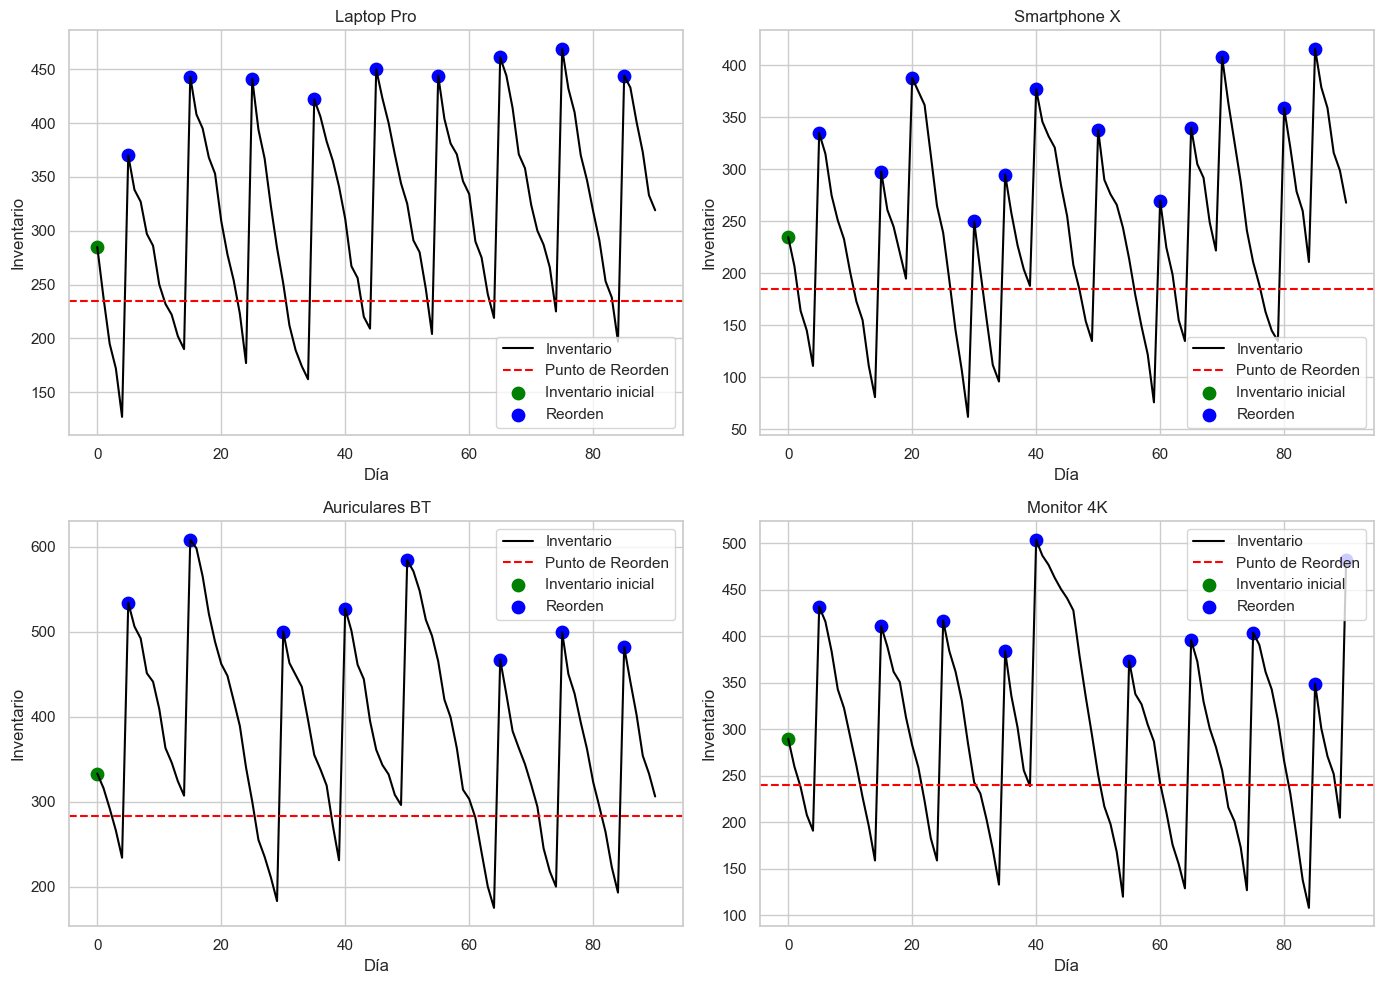

In [24]:
# Gráficas en cuadrícula 2x2
fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

for i, prod in enumerate(productos[:4]):  # mostramos 4 productos en 2x2
    ax = axes[i]
    subset = df_simulacion[df_simulacion['Producto']==prod]
    punto_reorden = resumen_inventario.loc[resumen_inventario['Producto']==prod, 'Punto_Reorden'].values[0]
    
    # Curva negra
    ax.plot(subset['Dia'], subset['Inventario'], color='black', label='Inventario')
    
    # Línea punteada roja (punto de reorden)
    ax.axhline(y=punto_reorden, color='red', linestyle='--', label='Punto de Reorden')
    
    # Punto verde inicial
    inicial = subset[subset['Evento']=='Inicial']
    ax.scatter(inicial['Dia'], inicial['Inventario'], color='green', s=80, label='Inventario inicial')
    
    # Puntos azules de reorden
    reordenes = subset[subset['Evento']=='Reorden']
    ax.scatter(reordenes['Dia'], reordenes['Inventario'], color='blue', s=80, label='Reorden')
    
    ax.set_title(prod)
    ax.set_xlabel("Día")
    ax.set_ylabel("Inventario")
    ax.legend()

plt.tight_layout()
plt.show()


Las gráficas muestran cómo evoluciona el inventario de cada producto a lo largo de 90 días, considerando la demanda diaria y las reglas de reorden. La línea negra representa el nivel de inventario que va disminuyendo con el consumo, mientras que la línea roja punteada indica el **punto de reorden**, es decir, el nivel crítico en el que conviene pedir más stock. El punto verde marca el **inventario inicial** en el día cero, y los puntos azules señalan los momentos en que se ejecuta un **reorden**, lo que provoca un aumento inmediato en el inventario. De esta manera, las gráficas permiten visualizar de forma clara el ciclo de consumo y reposición, mostrando cómo se evita la ruptura de stock gracias a la estrategia de reorden cada 5 días.


--- 
## Ejemplo 2: Predicción de Abandono de Clientes (Churn)

En este segundo ejemplo, utilizamos **Machine Learning** para predecir qué clientes tienen mayor probabilidad de cancelar su suscripción a un servicio. Esto permite a los equipos de retención actuar *antes* de que el cliente se vaya.

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Simulamos datos de clientes de una empresa de telecomunicaciones/SaaS
np.random.seed(123)
n_clientes = 1000

antiguedad = np.random.randint(1, 72, n_clientes)
gasto_mensual = np.random.uniform(20, 150, n_clientes)
soporte_llamadas = np.random.randint(0, 8, n_clientes)

# Lógica simulada para el Churn (mayor llamadas de soporte y menor antigüedad aumentan el riesgo)
prob_churn = 1 / (1 + np.exp(-(-2 + 0.1 * soporte_llamadas - 0.03 * antiguedad - 0.01 * gasto_mensual)))
churn = (np.random.rand(n_clientes) < prob_churn).astype(int)

df_churn = pd.DataFrame({
    'Antiguedad_Meses': antiguedad,
    'Gasto_Mensual': gasto_mensual,
    'Llamadas_Soporte': soporte_llamadas,
    'Churn': churn
})

print(f"Tasa de abandono global en la muestra: {df_churn['Churn'].mean():.2%}")
df_churn.head()

Tasa de abandono global en la muestra: 3.80%


,Antiguedad_Meses,Gasto_Mensual,Llamadas_Soporte,Churn
0,67,110.270193,1,0
1,18,136.334113,6,0
2,58,117.916566,3,0
3,48,87.637755,7,0
4,33,84.829468,7,0


### Entrenamiento del Modelo Predictivo
Dividimos los datos en conjuntos de entrenamiento y prueba, y entrenamos un clasificador de Bosque Aleatorio (`Random Forest`) para aprender los patrones de abandono.

In [27]:
X = df_churn[['Antiguedad_Meses', 'Gasto_Mensual', 'Llamadas_Soporte']]
y = df_churn['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print("Reporte de Clasificación del Modelo:")
print(classification_report(y_test, y_pred))

Reporte de Clasificación del Modelo:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       194
           1       0.00      0.00      0.00         6

    accuracy                           0.97       200
   macro avg       0.48      0.50      0.49       200
weighted avg       0.94      0.97      0.96       200



c:\Users\eraso\Desktop\Git\Academico\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\eraso\Desktop\Git\Academico\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\eraso\Desktop\Git\Academico\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

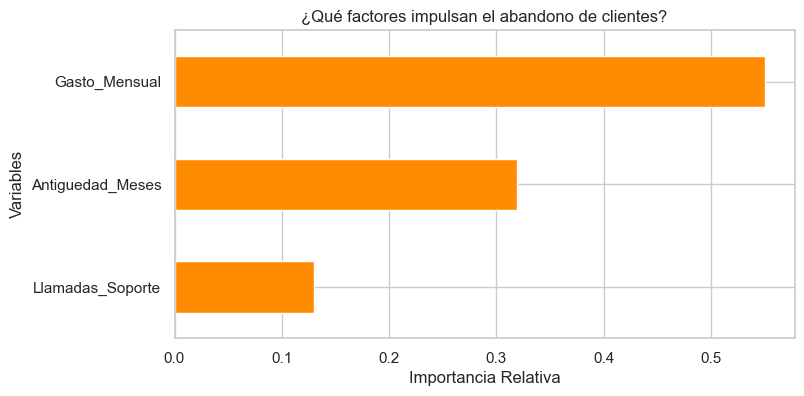

In [28]:
# Importancia de las variables según el modelo
importancias = pd.Series(modelo.feature_importances_, index=X.columns)

plt.figure(figsize=(8, 4))
importancias.sort_values().plot(kind='barh', color='darkorange')
plt.title('¿Qué factores impulsan el abandono de clientes?')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variables')
plt.show()

--- 
## Conclusión

A través de estos dos ejemplos hemos visto cómo la analítica de datos genera un valor tangible:
1. **Eficiencia Operativa:** Automatizando la gestión de inventarios para evitar costos innecesarios y roturas de stock.
2. **Crecimiento y Retención:** Anticipándose al comportamiento del usuario mediante Machine Learning para proteger los ingresos de la compañía.

*La analítica de datos deja de ser una opción para convertirse en el núcleo de la ventaja competitiva.*